In [52]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
ROOT_DIR = Path.cwd().parent

data_path = ROOT_DIR / "data"

In [54]:
rfqs = pd.read_csv(data_path / "rfqs.csv")

In [55]:
rfqs.head(10) 

,rfq_id,product_type,underlyings,basket_type,autocall_barrier_pct,protection_barrier_pct,no_call_period_months,observation_frequency,quoted_implied_vol,notional_credits,counterparty,trader_id,requested_date,executed,start_date,end_date,avg_duration_months
0,RFQ-000000,Kessel Run Snowball,CLNE|DRC,worst_of,1.0000,0.5424,3,Monthly,0.2455,250000,Jabba Asset Management,TRD-015,2022-09-08,False,2022-09-08,2030-01-22,NaN
1,RFQ-000001,Kessel Run Snowball,SITH|WOOK,worst_of,1.0000,0.6258,6,1Y,0.2365,100000,Corellian Capital,TRD-010,2022-06-10,False,2022-06-10,2030-08-09,NaN
2,RFQ-000002,Death Star Phoenix Note,MNDO|NABO,worst_of,1.0152,0.5899,2,1M,0.2011,100000,Nal Hutta Traders,TRD-026,2019-05-27,False,2019-05-27,2028-12-09,NaN
3,RFQ-000003,Kessel Run Snowball,TECH|SITH,worst_of,1.0000,0.5944,4,6M,0.2755,250000,Chandrila Sovereign Fund,TRD-032,2021-09-01,True,2021-09-01,2026-01-30,30.71
4,RFQ-000004,Mandalorian Twin-Win,JEDI,single,1.3149,0.7880,0,3 months,0.1266,100000,Corellian Capital,TRD-034,2023-04-06,False,2023-04-06,2026-07-13,NaN
5,RFQ-000005,Holocron Reverse Convertible,KYBR,single,1.3492,0.7391,0,3M,0.2032,500000,Jabba Asset Management,TRD-003,2024-05-08,False,2024-05-08,2032-09-09,NaN
6,RFQ-000006,Sith Eternal Snowball,REBL|CLNE|JEDI,worst_of,1.0000,0.5952,2,1Y,0.1739,100000,Chandrila Sovereign Fund,TRD-012,2020-03-23,False,2020-03-23,2030-01-22,NaN
7,RFQ-000007,Kessel Run Snowball,JEDI|CORL,worst_of,1.0000,0.5567,3,2M,0.2418,100000,Banco de Coruscant,TRD-027,2017-10-06,False,2017-10-06,2025-12-25,NaN
8,RFQ-000008,Mandalorian Twin-Win,POBK,single,1.2147,0.7669,0,1M,0.4630,500000,Corellian Capital,TRD-022,2021-02-01,True,2021-02-04,2028-02-05,14.27
9,RFQ-000009,Mandalorian Twin-Win,MNDO,single,1.1783,0.8218,0,1M,0.4066,500000,Alderaan Wealth Partners,TRD-012,2017-04-26,False,2017-04-26,2019-10-01,NaN


In [56]:
display(rfqs.info())
display(rfqs.describe())

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rfq_id                  25000 non-null  str    
 1   product_type            25000 non-null  str    
 2   underlyings             25000 non-null  str    
 3   basket_type             25000 non-null  str    
 4   autocall_barrier_pct    25000 non-null  float64
 5   protection_barrier_pct  25000 non-null  float64
 6   no_call_period_months   25000 non-null  int64  
 7   observation_frequency   25000 non-null  str    
 8   quoted_implied_vol      25000 non-null  float64
 9   notional_credits        25000 non-null  int64  
 10  counterparty            25000 non-null  str    
 11  trader_id               25000 non-null  str    
 12  requested_date          25000 non-null  str    
 13  executed                25000 non-null  bool   
 14  start_date              25000 non-null  str    
 

None

,autocall_barrier_pct,protection_barrier_pct,no_call_period_months,quoted_implied_vol,notional_credits,avg_duration_months
count,25000.000000,25000.000000,25000.000000,25000.000000,2.500000e+04,13796.000000
mean,1.139004,0.663538,1.480160,0.278661,6.764120e+05,39.782783
std,0.147257,0.096473,2.016732,0.089055,1.695565e+06,22.105132
min,0.950000,0.500000,0.000000,0.093600,1.000000e+05,0.160000
25%,1.000000,0.600000,0.000000,0.217700,1.000000e+05,23.567500
50%,1.152700,0.622500,0.000000,0.274250,2.500000e+05,35.380000
75%,1.276100,0.760900,3.000000,0.330500,5.000000e+05,51.952500
max,1.400000,0.850000,6.000000,0.599700,2.000000e+07,127.710000


`rfqs.info()`
- Solo nulos en `avg_duration_months`, como se esperaba del enunciado. Falta comprobar que son esos y solo esos los `executed = True`.
- `observation_frequency` es `str`.
- `requested_date` es `str`
- `start_date` y `end_date` son `str` (como primero se hace el preprocesamiento y luego la integración/preparación para el modelo yo lo arreglaria aunque vayamos a tirarlo). Además no tienen nulos (contradicción con el enunciado o etiquetados de otra forma).

`rfqs.describe()`
- `avg_duration_months` tiene maximo de 127.71 con 39.8 de media, revisaremos la distribución par distintas variables categóricas. ¿Es una cola larga o son valores atípicos?
- `auttocall_barrier_pct` tiene un mínimo de 0.95, por debajo de 1 (el nivel inicial). Revisar.


In [57]:
print("Cardinalidad counterparty:", rfqs['counterparty'].nunique())
print("Cardinalidad trader_id:", rfqs['trader_id'].nunique())

Cardinalidad counterparty: 8
Cardinalidad trader_id: 39


In [58]:
# Comprobamos si hay rfq_id es una clave única
print("rfq_id duplicados: ", rfqs["rfq_id"].duplicated().sum())

# Comprobamos si hay filas duplicadas
# Excluimos rfq_id porque ya sabemos que las claves son únicas
rfqs_col_noid = rfqs.columns.drop(['rfq_id'])
print("RFQ duplicados (rfq_id excluido): ", rfqs.duplicated(rfqs_col_noid).sum())

rfq_id duplicados:  0
RFQ duplicados (rfq_id excluido):  0


La key `rfq_id` es única.
Además, no hay ninguna RFQ igual (excluyendo `rfq_id` de la comparativa). Conviene detenerse y preguntarse si, en caso de existir dos RFQ iguales (exceptuando su ID), podríamos asegurar que es un registro duplicado. A simple vista no podemos asegurarlo, pero las coincidencias exactas de `float` y que sean ordenes distintas ejecutadas en el mismo momento por la misma `counterparty` es sospechoso.

In [59]:
# Comprobamos el número de nulos por feature
# Calculado en rfqs.info() pero con el numero de nulos
print("Número de nulos por feature:\n", rfqs.isna().sum())

# Comprobamos el número de nulos por fila
# Sabemos previamente que sera 1 en aquellas que es nulo `avg_duration_months`
print("\nNúmero de filas por cantidad de nulos:\n", rfqs.isna().sum(axis=1).value_counts())

Número de nulos por feature:
 rfq_id                        0
product_type                  0
underlyings                   0
basket_type                   0
autocall_barrier_pct          0
protection_barrier_pct        0
no_call_period_months         0
observation_frequency         0
quoted_implied_vol            0
notional_credits              0
counterparty                  0
trader_id                     0
requested_date                0
executed                      0
start_date                    0
end_date                      0
avg_duration_months       11204
dtype: int64

Número de filas por cantidad de nulos:
 0    13796
1    11204
Name: count, dtype: int64


Solo hay nulos en `avg_duration_months` como sabíamos de antemano por el enunciado. Debemos comprobar posteriormente que no existen valores nulos en esta columna distintos de aquellos con `executed = False`.

In [60]:
rfqs['requested_date'] = pd.to_datetime(rfqs['requested_date'])
rfqs['end_date'] = pd.to_datetime(rfqs['end_date'])
rfqs['start_date'] = pd.to_datetime(rfqs['start_date'])

In [61]:

violacion_1 = rfqs['requested_date'] > rfqs['start_date']
print(f"Filas con requested_date > start_date: {violacion_1.sum()}")

violacion_2 = rfqs['start_date'] > rfqs['end_date']
print(f"Filas con start_date > end_date: {violacion_2.sum()}")

ejecutadas = rfqs[rfqs['executed']]
violacion_3 = ejecutadas['avg_duration_months'] < ejecutadas['no_call_period_months']
print(f"Filas con avg_duration_months < no_call_period_months: {violacion_3.sum()}")

Filas con requested_date > start_date: 0
Filas con start_date > end_date: 0
Filas con avg_duration_months < no_call_period_months: 0


Los valores temporales comprobados hasta el momento mantienen coherencia con su significado.

In [62]:
rfqs['observation_frequency'].unique()

<StringArray>
[   'Monthly',         '1Y',         '1M',         '6M',   '3 months',
         '3M',         '2M',          'M',          'Q',        '12M',
          'Y',  'Quarterly',         '1D',    '1 month', 'trimestral',
      'anual',    'mensual',     'Annual']
Length: 18, dtype: str

Se tienen 18 categorias distintas en `obsrvation_frequency` para lo que probablemente sean menos frecuencias reales pero codificadas de distinta forma.

In [63]:
rfqs['n_underlyings'] = rfqs['underlyings'].str.count(r'\|') + 1

rfqs.value_counts(["basket_type", "n_underlyings"])

basket_type  n_underlyings
worst_of     2                12379
single       1                 8461
worst_of     3                 4160
Name: count, dtype: int64

Solo las solicitudes de cotización con un solo subyacente estan marcadas como 'single' en `basket_type`. Las que tienen más de uno siempre estan tienen 'worst_of' en `basket_type`

In [64]:
rfqs.value_counts(['executed','avg_duration_months'], dropna = False)

executed  avg_duration_months
False     NaN                    11204
True      24.43                     10
          24.10                      9
          24.29                      9
          32.89                      9
                                 ...  
          71.26                      1
          54.31                      1
          15.27                      1
          12.89                      1
          89.41                      1
Name: count, Length: 6507, dtype: int64

`avg_duration_months` esta poblado si y solo si `executed = True`. No existen `executed = False` con valor de `avg_duration_months` distinto de `NaN`

In [65]:
# % Global de ejecución
print(f"Tasa global de ejecución: {rfqs["executed"].mean()*100:.2f}")
display(pd.crosstab(rfqs['product_type'], rfqs['executed'], normalize='index') * 100)
display(pd.crosstab(rfqs['counterparty'], rfqs['executed'], normalize='index') * 100)
display(pd.crosstab(rfqs['trader_id'], rfqs['executed'], normalize='index') * 100)

Tasa global de ejecución: 55.18


executed,False,True
product_type,,
Death Star Phoenix Note,44.961427,55.038573
Holocron Reverse Convertible,44.240283,55.759717
Kessel Run Snowball,45.398622,54.601378
Mandalorian Twin-Win,45.469639,54.530361
Sith Eternal Snowball,44.615385,55.384615
Wretched Hive Digital,44.228462,55.771538


executed,False,True
counterparty,,
Alderaan Wealth Partners,44.133719,55.866281
Banco de Coruscant,44.852708,55.147292
Chandrila Sovereign Fund,44.896000,55.104000
Corellian Capital,45.446009,54.553991
First Order Financial,44.078735,55.921265
Jabba Asset Management,44.750486,55.249514
Kamino Cloning Trust,44.018987,55.981013
Nal Hutta Traders,46.364526,53.635474


executed,False,True
trader_id,,
TRD-001,43.478261,56.521739
TRD-002,43.670886,56.329114
TRD-003,47.900467,52.099533
TRD-004,46.452703,53.547297
TRD-005,42.145015,57.854985
TRD-006,42.301459,57.698541
TRD-007,45.673077,54.326923
TRD-008,44.480000,55.520000
TRD-009,44.748858,55.251142


No se observan en las tasas de ejecución por `product_type` ni por `counterparty` grandes diferencias.

In [66]:
print("Filas no nulas con `executed = False`:\n", rfqs[rfqs["executed"] == False][["start_date", "end_date"]].count())

display(rfqs[rfqs["executed"] == False][["requested_date", "start_date", "end_date"]])

false_req_eq_start = (rfqs["executed"] == False) & (rfqs["requested_date"] == rfqs["start_date"])
print("Número de filas `executed = False` con requested_date = start_date:\n", len(rfqs[false_req_eq_start]))

true_req_eq_start = (rfqs["executed"] == True) & (rfqs["requested_date"] == rfqs["start_date"])
print("Número de filas `executed = True` con requested_date = start_date:\n", len(rfqs[true_req_eq_start]))

Filas no nulas con `executed = False`:
 start_date    11204
end_date      11204
dtype: int64


,requested_date,start_date,end_date
0,2022-09-08,2022-09-08,2030-01-22
1,2022-06-10,2022-06-10,2030-08-09
2,2019-05-27,2019-05-27,2028-12-09
4,2023-04-06,2023-04-06,2026-07-13
5,2024-05-08,2024-05-08,2032-09-09
...,...,...,...
24986,2021-06-04,2021-06-04,2028-05-31
24990,2021-08-23,2021-08-23,2029-11-14
24996,2018-08-22,2018-08-22,2026-09-18
24997,2024-05-02,2024-05-02,2031-12-02


Número de filas `executed = False` con requested_date = start_date:
 11204
Número de filas `executed = True` con requested_date = start_date:
 2287


Para los casos `executed = False` comprobamos que siempre `requested_date = start_date`.
Para los casos `executed = True` comprobamos que no siempre `requested_date = start_date`.

In [67]:
rfqs['nominal_term_days'] = (rfqs['end_date'] - rfqs['start_date']).dt.days
rfqs['nominal_term_months'] = rfqs['nominal_term_days'] / 30.44

rfqs.groupby('executed')['nominal_term_months'].describe()

,count,mean,std,min,25%,50%,75%,max
executed,,,,,,,,
False,11204.0,71.873638,27.570771,24.014455,47.922142,71.780552,95.696452,119.973719
True,13796.0,71.946805,27.720359,24.014455,48.028909,71.681997,95.992116,119.973719


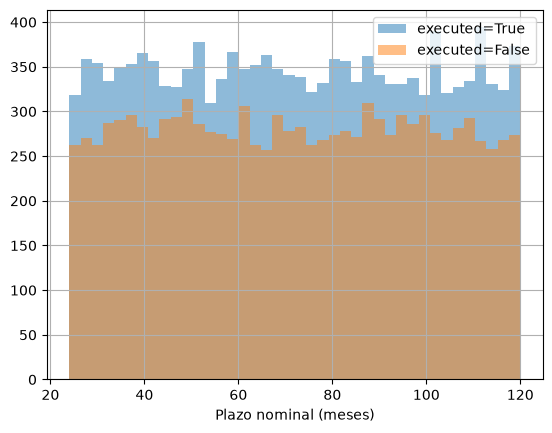

In [68]:
rfqs[rfqs['executed']]['nominal_term_months'].hist(bins=40, alpha=0.5, label='executed=True')
rfqs[~rfqs['executed']]['nominal_term_months'].hist(bins=40, alpha=0.5, label='executed=False')
plt.legend()
plt.xlabel('Plazo nominal (meses)')
plt.show()

In [69]:
rfqs.groupby(['product_type', 'executed'])['nominal_term_months'].describe()

count       mean        std  \
product_type                 executed                                 
Death Star Phoenix Note      False     1865.0  71.758463  27.805710   
                             True      2283.0  71.899065  27.407161   
Holocron Reverse Convertible False     1878.0  71.716756  27.618565   
                             True      2367.0  71.739526  27.543684   
Kessel Run Snowball          False     1845.0  71.953979  27.521194   
                             True      2219.0  71.608315  27.486379   
Mandalorian Twin-Win         False     1917.0  71.871566  27.925060   
                             True      2299.0  72.355103  27.956559   
Sith Eternal Snowball        False     1856.0  72.451565  27.193739   
                             True      2304.0  71.286040  27.451998   
Wretched Hive Digital        False     1843.0  71.489772  27.366132   
                             True      2324.0  72.779187  28.452310   

                                             min        25%        50%  \
product_type                 executed                                    
Death Star Phoenix Note      False     24.047306  47.503285  71.057819   
                             True      24.047306  47.733246  71.911958   
Holocron Reverse Convertible False     24.047306  48.012484  71.698423   
                             True      24.014455  48.012484  71.287779   
Kessel Run Snowball          False     24.047306  47.700394  72.273325   
                             True      24.014455  48.160315  71.123522   
Mandalorian Twin-Win         False     24.014455  46.977661  72.339028   
                             True      24.047306  48.012484  72.601840   
Sith Eternal Snowball        False     24.047306  49.540079  71.928384   
                             True      24.211564  48.184954  70.302234   
Wretched Hive Digital        False     24.047306  48.111038  71.287779   
                             True      24.014455  48.078187  74.178712   

                                             75%         max  
product_type                 executed                         
Death Star Phoenix Note      False     95.827858  119.973719  
                             True      94.825887  119.875164  
Holocron Reverse Convertible False     95.565046  119.908016  
                             True      95.532194  119.940867  
Kessel Run Snowball          False     95.597898  119.940867  
                             True      95.630749  119.973719  
Mandalorian Twin-Win         False     95.893561  119.875164  
                             True      96.484888  119.973719  
Sith Eternal Snowball        False     95.540407  119.940867  
                             True      95.203679  119.940867  
Wretched Hive Digital        False     95.630749  119.973719  
                             True      97.536137  119.973719

El plazo nominal (`nominal_term_months`) mantiene distribuciones prácticamente idénticas entre `executed = True` y `executed = False` dentro de cada `product_type` individual (medias, mediana y cuartiles muy próximos en los seis tipos), no solo en el agregado global. Esto confirma que `start_date`/`end_date` — pese a que el enunciado indica que solo existen si `executed = True` — están realmente poblados de forma consistente para toda RFQ en el momento de la solicitud, con independencia de si el cliente acaba ejecutando o no. Consideramos por tanto `nominal_term_months` una feature de entrada válida y disponible en el momento de cotizar.

In [70]:
ejecutadas = rfqs[rfqs['executed']]
violacion_4 = ejecutadas['avg_duration_months'] > ejecutadas['nominal_term_months']
print(f"Filas con avg_duration_months > nominal_term_months: {violacion_4.sum()} ({violacion_4.sum()/len(ejecutadas)*100:.1f}% del total de ejecutadas)")

Filas con avg_duration_months > nominal_term_months: 303 (2.2% del total de ejecutadas)


In [71]:
casos = ejecutadas[violacion_4][['rfq_id', 'product_type', 'counterparty', 'trader_id', 'requested_date', 'start_date', 'end_date',
                                    'nominal_term_months', 'avg_duration_months', 'no_call_period_months']]
display(casos.sort_values('avg_duration_months', ascending=False))

tasa_violacion = casos['product_type'].value_counts() / ejecutadas['product_type'].value_counts() * 100
display(tasa_violacion.sort_values(ascending=False))
tasa_violacion = casos['counterparty'].value_counts() / ejecutadas['counterparty'].value_counts() * 100
display(tasa_violacion.sort_values(ascending=False))
tasa_violacion_trader = casos['trader_id'].value_counts() / ejecutadas['trader_id'].value_counts() * 100
display(tasa_violacion_trader.sort_values(ascending=False))


,rfq_id,product_type,counterparty,trader_id,requested_date,start_date,end_date,nominal_term_months,avg_duration_months,no_call_period_months
6733,RFQ-006733,Wretched Hive Digital,Alderaan Wealth Partners,TRD-035,2018-12-25,2018-12-26,2028-12-25,119.973719,127.71,0
10963,RFQ-010963,Wretched Hive Digital,First Order Financial,TRD-034,2017-04-04,2017-04-06,2026-12-29,116.754271,126.60,0
5880,RFQ-005880,Wretched Hive Digital,Chandrila Sovereign Fund,TRD-012,2018-06-18,2018-06-21,2028-05-24,119.086728,125.48,0
6600,RFQ-006600,Wretched Hive Digital,Corellian Capital,TRD-008,2019-04-04,2019-04-05,2029-02-21,118.593955,123.18,0
14974,RFQ-014974,Wretched Hive Digital,Nal Hutta Traders,TRD-039,2023-07-31,2023-08-01,2033-05-14,117.411301,123.18,0
...,...,...,...,...,...,...,...,...,...,...
6027,RFQ-006027,Wretched Hive Digital,Alderaan Wealth Partners,TRD-005,2023-01-20,2023-01-25,2025-02-20,24.868594,25.10,0
22114,RFQ-022114,Wretched Hive Digital,Alderaan Wealth Partners,TRD-034,2019-07-18,2019-07-22,2021-08-07,24.540079,24.89,0
24045,RFQ-024045,Wretched Hive Digital,Nal Hutta Traders,TRD-033,2016-12-21,2016-12-25,2018-12-29,24.113009,24.72,0
24700,RFQ-024700,Sith Eternal Snowball,First Order Financial,TRD-025,2020-04-20,2020-04-25,2022-05-03,24.244415,24.56,5


product_type
Wretched Hive Digital           9.165232
Sith Eternal Snowball           2.083333
Kessel Run Snowball             0.630915
Mandalorian Twin-Win            0.521966
Death Star Phoenix Note         0.350416
Holocron Reverse Convertible    0.337981
Name: count, dtype: float64

counterparty
Alderaan Wealth Partners    3.049482
Chandrila Sovereign Fund    2.497096
First Order Financial       2.135026
Corellian Capital           2.122777
Kamino Cloning Trust        2.035048
Nal Hutta Traders           1.945289
Jabba Asset Management      1.935484
Banco de Coruscant          1.838024
Name: count, dtype: float64

trader_id
TRD-010    4.098361
TRD-006    3.089888
TRD-038    3.021978
TRD-011    2.997275
TRD-003    2.985075
TRD-023    2.941176
TRD-008    2.881844
TRD-017    2.849003
TRD-025    2.795031
TRD-002    2.528090
TRD-021    2.513966
TRD-039    2.513966
TRD-034    2.484472
TRD-016    2.479339
TRD-024    2.479339
TRD-001    2.472527
TRD-037    2.419355
TRD-027    2.395210
TRD-007    2.359882
TRD-018    2.356021
TRD-005    2.349869
TRD-035    2.191781
TRD-013    2.127660
TRD-015    2.064897
TRD-029    2.046784
TRD-026    2.023121
TRD-028    1.886792
TRD-022    1.866667
TRD-032    1.794872
TRD-019    1.775148
TRD-014    1.666667
TRD-009    1.652893
TRD-033    1.618123
TRD-031    1.617251
TRD-020    1.047120
TRD-004    0.946372
TRD-030    0.911854
TRD-012    0.872093
TRD-036    0.285714
Name: count, dtype: float64

La mayoría de violaciones de `avg_duration_months > nominal_term_months` (~10%) se concentra en un `product_type = Wretched Hive Digital`.

Para `counterparty` y `trader_id` se observan distribciones continuas y sin outliers, a diferencia del salto claro en `product_id`. Quedan descartadas como responsables.

In [72]:
casos_con_exceso = casos.copy()
casos_con_exceso['exceso'] = ejecutadas.loc[casos_con_exceso.index, 'avg_duration_months'] - ejecutadas.loc[casos_con_exceso.index, 'nominal_term_months']

es_whd = casos_con_exceso['product_type'] == 'Wretched Hive Digital'

print("Exceso (meses) - Wretched Hive Digital:")
print(casos_con_exceso[es_whd]['exceso'].describe())

print("\nExceso (meses) - Resto de product_types:")
print(casos_con_exceso[~es_whd]['exceso'].describe())

Exceso (meses) - Wretched Hive Digital:
count    213.000000
mean       2.551523
std        2.498730
min        0.005834
25%        0.757543
50%        1.691327
75%        3.576465
max       13.858607
Name: exceso, dtype: float64

Exceso (meses) - Resto de product_types:
count    90.000000
mean      1.900644
std       2.026481
min       0.009816
25%       0.389566
50%       1.166465
75%       2.923213
max       8.951537
Name: exceso, dtype: float64


In [73]:
rfqs.groupby('product_type')['no_call_period_months'].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Death Star Phoenix Note,4148.0,1.484812,1.119359,0.0,0.0,1.0,2.0,3.0
Holocron Reverse Convertible,4245.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Kessel Run Snowball,4064.0,4.503937,1.124092,3.0,3.0,5.0,6.0,6.0
Mandalorian Twin-Win,4216.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Sith Eternal Snowball,4160.0,3.014663,2.005409,0.0,1.0,3.0,5.0,6.0
Wretched Hive Digital,4167.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [74]:
rfqs.groupby('product_type')['autocall_barrier_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Death Star Phoenix Note,4148.0,1.000013,0.028829,0.9500,0.975075,1.00020,1.024500,1.0500
Holocron Reverse Convertible,4245.0,1.275507,0.071216,1.1501,1.214100,1.27640,1.336400,1.3999
Kessel Run Snowball,4064.0,1.000000,0.000000,1.0000,1.000000,1.00000,1.000000,1.0000
Mandalorian Twin-Win,4216.0,1.275975,0.072505,1.1500,1.213875,1.27435,1.340025,1.4000
Sith Eternal Snowball,4160.0,1.000000,0.000000,1.0000,1.000000,1.00000,1.000000,1.0000
Wretched Hive Digital,4167.0,1.274063,0.072212,1.1501,1.211100,1.27370,1.336100,1.3999


In [75]:
rfqs.groupby('product_type')['protection_barrier_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Death Star Phoenix Note,4148.0,0.625620,0.043306,0.5500,0.588000,0.62610,0.663000,0.70
Holocron Reverse Convertible,4245.0,0.774233,0.043331,0.7000,0.736700,0.77370,0.811700,0.85
Kessel Run Snowball,4064.0,0.574432,0.043331,0.5000,0.536400,0.57465,0.611300,0.65
Mandalorian Twin-Win,4216.0,0.800253,0.028757,0.7501,0.775000,0.80080,0.824600,0.85
Sith Eternal Snowball,4160.0,0.600528,0.028674,0.5500,0.575975,0.60095,0.625025,0.65
Wretched Hive Digital,4167.0,0.600000,0.000000,0.6000,0.600000,0.60000,0.600000,0.60


In [76]:
pd.crosstab(rfqs['product_type'], rfqs['observation_frequency'], normalize='index') * 100

observation_frequency,1 month,12M,1D,1M,1Y,2M,3 months,3M,6M,Annual,M,Monthly,Q,Quarterly,Y,anual,mensual,trimestral
product_type,,,,,,,,,,,,,,,,,,
Death Star Phoenix Note,2.193828,0.843780,2.555448,24.783028,6.388621,7.883317,2.217936,21.745419,14.392478,0.554484,2.386692,2.868852,2.386692,2.434908,0.771456,0.699132,2.507232,2.386692
Holocron Reverse Convertible,3.109541,0.918728,2.449941,24.570082,6.289753,7.585395,2.049470,22.120141,14.723204,0.588928,2.449941,2.614841,2.332155,2.473498,0.659600,0.588928,2.614841,1.861013
Kessel Run Snowball,2.583661,0.664370,3.149606,24.926181,6.176181,7.972441,2.632874,21.087598,14.148622,0.639764,2.632874,2.485236,2.263780,2.632874,0.615157,0.885827,2.362205,2.140748
Mandalorian Twin-Win,2.964896,0.711575,2.917457,24.857685,6.380455,8.183112,2.300759,21.394687,14.302657,0.782732,2.514231,2.561670,2.324478,2.158444,0.521822,0.426945,2.443074,2.253321
Sith Eternal Snowball,2.475962,0.697115,3.149038,24.615385,6.346154,7.764423,1.995192,20.264423,14.807692,0.793269,2.379808,2.908654,2.163462,2.211538,0.745192,0.649038,3.125000,2.908654
Wretched Hive Digital,2.447804,0.743940,2.855772,24.430046,6.839453,8.495320,2.231821,20.518359,14.446844,0.575954,3.263739,2.639789,2.111831,1.919846,0.887929,0.503960,2.951764,2.135829


Detectamos 303 RFQs ejecutadas (2.2% del total) donde la duración real (`avg_duration_months`) supera el vencimiento nominal del contrato (`nominal_term_months`) — algo imposible según la regla de negocio, ya que un autocallable no puede durar más que su propio vencimiento.

Se concentran casi por completo en `product_type = Wretched Hive Digital` (tasa de violación 9.17%, frente a un máximo de 2.08% en el resto). Descartamos como causa `no_call_period_months`, `autocall_barrier_pct` y `observation_frequency` (otros productos comparten esos mismos valores sin mostrar el problema), así como `counterparty`/`trader_id` (sus tasas de violación varían de forma continua, sin ningún salto anómalo). Con las columnas disponibles no podemos identificar el mecanismo causal concreto.

**Decisión**: excluimos estas 303 filas del entrenamiento. No podemos determinar si el error está en el target o en las fechas del contrato, así que no confiamos en ninguna de las dos columnas para estos casos; el volumen excluido es pequeño (2.2% del total, y `Wretched Hive Digital` conserva 2.111 de 2.324 filas ejecutadas) y no compromete el tamaño muestral.

In [77]:
observation_frequency_map = {
    'Monthly': 'Monthly', '1M': 'Monthly', 'M': 'Monthly',
    'mensual': 'Monthly', '1 month': 'Monthly',
    '2M': 'Bimonthly',
    '3 months': 'Quarterly', '3M': 'Quarterly', 'Q': 'Quarterly',
    'Quarterly': 'Quarterly', 'trimestral': 'Quarterly',
    '6M': 'Semiannual',
    '1Y': 'Annual', '12M': 'Annual', 'Y': 'Annual',
    'Annual': 'Annual', 'anual': 'Annual',
    '1D': 'Daily',
}

display(ejecutadas['observation_frequency'].unique())

ejecutadas['observation_frequency_clean'] = ejecutadas['observation_frequency'].map(observation_frequency_map)

display(ejecutadas['observation_frequency_clean'].unique())

print(ejecutadas['observation_frequency_clean'].isna().sum())

<StringArray>
[        '6M',         '1M',         '3M',    'Monthly',         '2M',
        '12M',         '1Y',          'Y',  'Quarterly',         '1D',
    '1 month', 'trimestral',      'anual',   '3 months',    'mensual',
          'M',          'Q',     'Annual']
Length: 18, dtype: str

<StringArray>
['Semiannual', 'Monthly', 'Quarterly', 'Bimonthly', 'Annual', 'Daily']
Length: 6, dtype: str

0


In [78]:
ejecutadas_limpias = ejecutadas[~violacion_4]

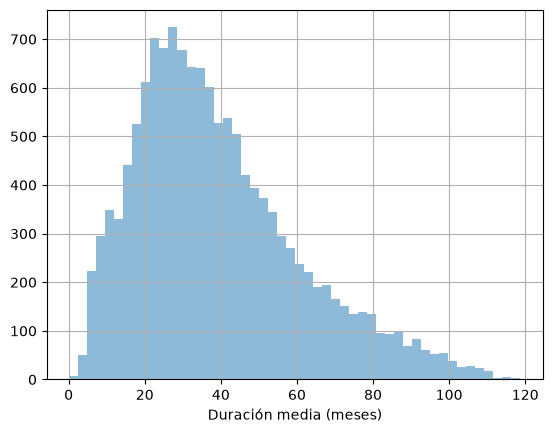

In [79]:
ejecutadas_limpias['avg_duration_months'].hist(bins=50, alpha=0.5)
plt.xlabel('Duración media (meses)')
plt.show()

La distribución de `avg_duration_months` tiene una fuerte asimetría a la derecha, unimodal, con un pico alrededor de los 25-30 meses y una cola larga que se extiende hasta >120.

Esto es coherente con el mecanismo de negocio: "acumulación" de cancelaciones relativamente pronto (una vez pasado el `no_call_period`, cualquier fecha de observación pudede disparar el autocall), y luego una cola decreciente de productos que tardan más en cruzar la barrera o que llegan al vencimiento nominal.

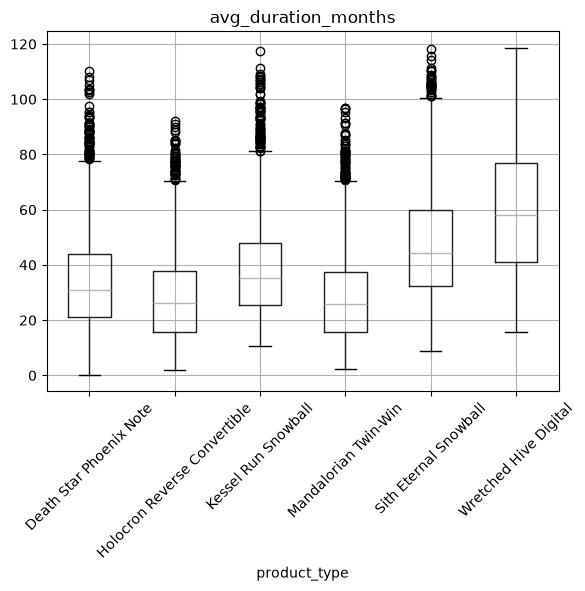

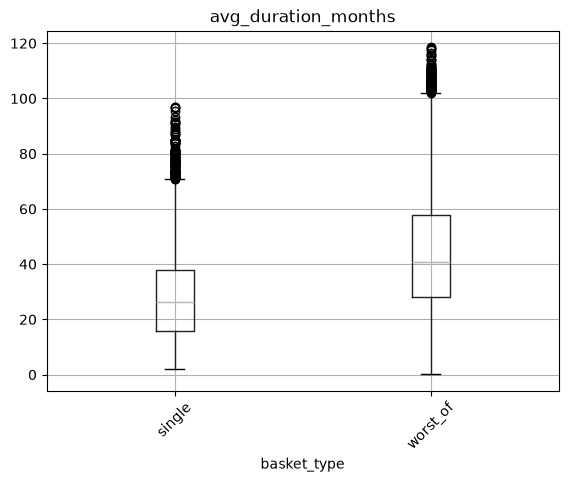

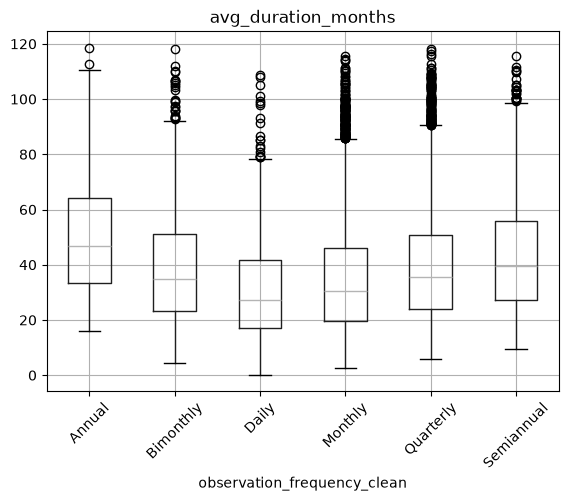

In [80]:
for col in ['product_type', 'basket_type', 'observation_frequency_clean']:
    ejecutadas_limpias.boxplot(column='avg_duration_months', by=col, rot=45)
    plt.suptitle('')
    plt.show()

- `product_type`: incluso tras excluir los casos iconsistentes, `Wretched Hive Digital` mantiene una duración sistematiacamente mayor que el resto de productos.
- `basket_type`: `worst_of` muestra mediana y dispersión claramente mayores que `single`. Es la confirmación empírica directa de la hipótesis de negocio que construimos: más subyacentes en la cesta, más probabiliad de que uno se quede rezagado, mayor duración.
- `observation_frequency_clean`: `Annual` tiene la mediana más alta (40-50) y `Daily` la más baja (20-30), con el resto escaladas en orden. Esto tiene sentido de negocio, si obsrvas con poca frecuencia, aunque la condición de autocall ya se cumpliera entre dos fechas de observación, no se detecta hasta la siguiente ventana (es un efecto de la medición).

In [81]:
numericas = ['autocall_barrier_pct', 'protection_barrier_pct', 'no_call_period_months',
             'quoted_implied_vol', 'notional_credits', 'nominal_term_months']

ejecutadas_limpias[numericas + ['avg_duration_months']].corr()['avg_duration_months'].sort_values(ascending=False)

avg_duration_months       1.000000
nominal_term_months       0.529484
no_call_period_months     0.092513
notional_credits          0.001520
autocall_barrier_pct     -0.009951
quoted_implied_vol       -0.065059
protection_barrier_pct   -0.337362
Name: avg_duration_months, dtype: float64

In [82]:
ejecutadas_limpias[['autocall_barrier_pct', 'protection_barrier_pct']].corr()

,autocall_barrier_pct,protection_barrier_pct
autocall_barrier_pct,1.000000,0.629251
protection_barrier_pct,0.629251,1.000000


In [83]:
ejecutadas_limpias.groupby('product_type').apply(
    lambda g: g['autocall_barrier_pct'].corr(g['avg_duration_months'])
)

c:\Users\marco\Documents\Juniors_2026_Q3\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\marco\Documents\Juniors_2026_Q3\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


product_type
Death Star Phoenix Note         0.212550
Holocron Reverse Convertible    0.188218
Kessel Run Snowball                  NaN
Mandalorian Twin-Win            0.208767
Sith Eternal Snowball                NaN
Wretched Hive Digital           0.120906
dtype: float64

In [84]:
ejecutadas_limpias.groupby('product_type').apply(
    lambda g: g['quoted_implied_vol'].corr(g['avg_duration_months'])
)

product_type
Death Star Phoenix Note         0.341173
Holocron Reverse Convertible   -0.550490
Kessel Run Snowball             0.372485
Mandalorian Twin-Win           -0.545616
Sith Eternal Snowball           0.293991
Wretched Hive Digital           0.035053
dtype: float64

In [85]:
ejecutadas_limpias.groupby('product_type').apply(
    lambda g: g['protection_barrier_pct'].corr(g['avg_duration_months'])
)

product_type
Death Star Phoenix Note        -0.030117
Holocron Reverse Convertible    0.011227
Kessel Run Snowball             0.003480
Mandalorian Twin-Win            0.000388
Sith Eternal Snowball          -0.019857
Wretched Hive Digital                NaN
dtype: float64

In [86]:
ejecutadas_limpias.groupby('product_type').apply(
    lambda g: g['nominal_term_months'].corr(g['avg_duration_months'])
)

product_type
Death Star Phoenix Note         0.574765
Holocron Reverse Convertible    0.320622
Kessel Run Snowball             0.647561
Mandalorian Twin-Win            0.320553
Sith Eternal Snowball           0.778243
Wretched Hive Digital           0.897788
dtype: float64

In [87]:
ejecutadas_limpias.groupby('product_type').apply(
    lambda g: g['no_call_period_months'].corr(g['avg_duration_months'])
)

product_type
Death Star Phoenix Note         0.065077
Holocron Reverse Convertible         NaN
Kessel Run Snowball             0.091009
Mandalorian Twin-Win                 NaN
Sith Eternal Snowball           0.115638
Wretched Hive Digital                NaN
dtype: float64

- `autocall_barrier_pct`: positiva y consistente en los cuatro productos donde hay variación (0.12-0.21). Esto confirma la hipótesis que planteamos, a barrera más alta, más dificil de superar y por tanto, mayor duración. Quedaba enmascarado en la correlación global porque las diferencias entre productos dominaban sobre la relación dentro de cada producto.
- `protection_barrier_pct`: Dentro de cada producto, la correlación es prácticamente cero en los cinco grupos (-0.03-0.01). La correlación global de -0.33 no sobrevive al control por `product_type`. Se confirma que no hay relación causal real, tal como razonamos.
- `nominal_term_months`: positiva y consistente en todos los productos. Tiene sentido puesto que actua como techo físico de `avg_duraation_months` (más aún después de excluir las 303 filas que violaban esa cota), así que un plazonominal mayor mecánicamente permite duraciones mayores.
    - `Wretched Hive Digital` destaca con 0.898, muy por encima de los demás, esto es coherente con lo visto en el boxplot, y es que es el producto con la mediana de duración más alta, lo que sugiere que este producto en particular no suele cancelarse anticipadamente. 
    - `Holocron Reverse Convertible` y `Mandalorian Twin-Win` muesran la correlación más debil (~0.32), curiosamente los productos que comparten la misma barrera más elevada (~1.27) que  `Wretched Hive Digital`, así que el nivel de la barrera pos si solo no explica esta diferencia.
- `quoted_implied_vol`: El signo se invierte entre familias de producto: positiva y notable en `Death Star`, `Kessel Run` y `Sith Eternal` (0.29-0.37), fuertemente negativa en `Holocron` y `Mandalorian` (-0.55), y prácticamente nula en `Wretched Hive Digital` (0.035). La correlación global de -0.065 no significa que no haya relación, es el promedio de dos efectos opuesto que casi se cancelan entre sí.
    - Los productos con correlación **positiva** son precisamente aquellos con `autocall_barrier_pct` en torno a 1, y también los que cuentan con `no_call_period_months` variable.
    - Los productos con correlación **negativa** son aquellos con `autocall_barrier_pct` bien por encima del nivel inicial, y junto con `Wretched Hive Digital`, los tres con `no_call_period_months` fijo en 0.

Comprobamos si existe una relación positiva entre `quoted_implied_vol` y `no_call_period_months` para los productos con volatilidad variable. Si la mesa tiende a asignar periodos de bloqueo inicial más largoa a operaciones con mayor volatilidad cotizada, se produciria una correlación positiva "artificial" entre `quoted_implied_vol` y `autocall_barrier_pct`.

In [88]:
for pt in ['Death Star Phoenix Note', 'Kessel Run Snowball', 'Sith Eternal Snowball']:
    sub = ejecutadas_limpias[ejecutadas_limpias['product_type'] == pt]
    print(pt, sub['quoted_implied_vol'].corr(sub['no_call_period_months']))

Death Star Phoenix Note 0.006734057152629336
Kessel Run Snowball -0.0185354125162222
Sith Eternal Snowball -0.012979193522856031


Los tres valores (0.007, -0.019, -0.013) descartan la relación entre la volatilidad cotizada y el periodo de bloqueo para los productos con `no_call_period_months` variable. 

Descartada la relación a través del periodo de bloqueo, y utilizando los datos provistos, podemos especular basandonos en la teoría, sin la posibilidad de confirmarlo, una relación a través de `autocall_barrier_pct`: 
- Barrera ≈ 1.0 (Death Star, Kessel Run, Sith Eternal): en una cesta worst-of, el valor relevante es el mínimo entre varios subyacentes. Cuanta más volatilidad tiene cada uno, mayor es la dispersión de resultados posibles — y el mínimo de varios activos dispersos tiende a ser, en promedio, más bajo que el mínimo de varios activos poco dispersos (aunque todos partan del mismo nivel esperado). Si la barrera está justo al 100%, más volatilidad empuja el mínimo de la cesta hacia abajo con más frecuencia, dificultando que supere la barrera — de ahí que más vol se asocie a mayor duración.
- Barrera ≈ 1.27 (Holocron, Mandalorian): aquí hace falta una subida sustancial para cruzar la barrera en absoluto. Con poca volatilidad, es improbable que el subyacente más débil llegue nunca tan alto (el producto tendería a agotar el plazo nominal sin autocall). Con más volatilidad, aumenta la probabilidad de que en algún momento se produzca un movimiento lo bastante extremo como para cruzar ese umbral elevado — y cuando eso ocurre, tiende a ser relativamente pronto en la vida del producto. De ahí el signo contrario.

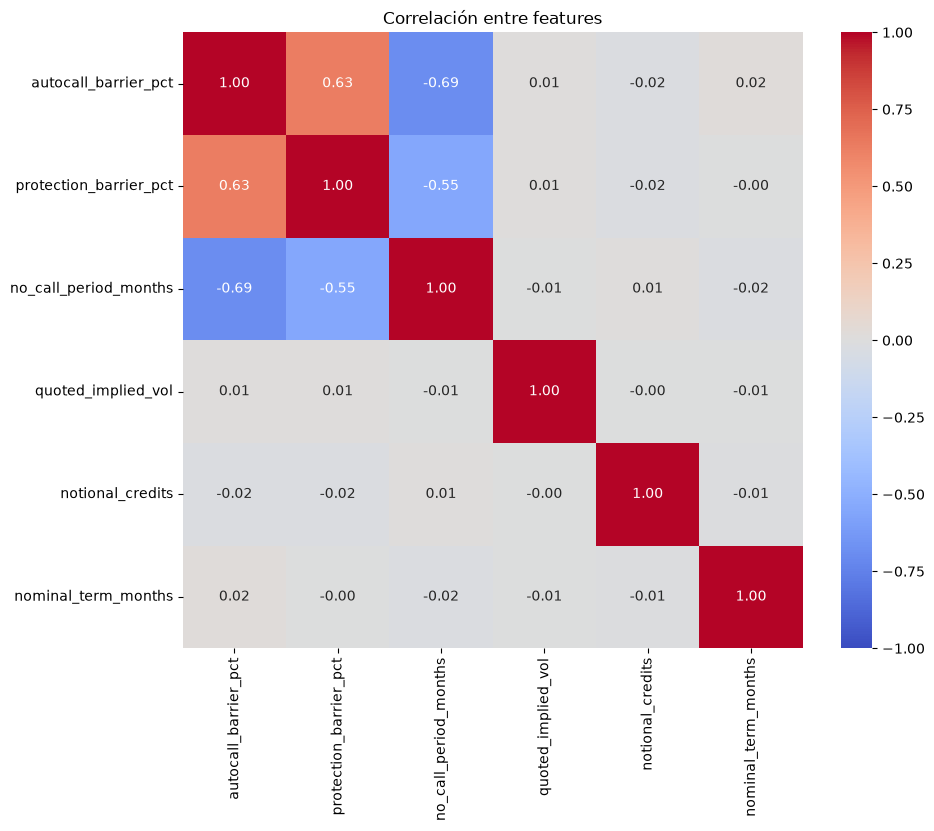

In [91]:
numericas_todas = ['autocall_barrier_pct', 'protection_barrier_pct', 'no_call_period_months',
                    'quoted_implied_vol', 'notional_credits', 'nominal_term_months']

plt.figure(figsize=(10, 8))
sns.heatmap(ejecutadas_limpias[numericas_todas].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre features')
plt.show()

La correlación más fuerte y esperada es la de las dos barreras entre sí (0.629). Las correlaciones de `autocall_barrier_pct` y `protection_barrier_pct` con `no_call_period_months` (-0.691 y -0.553) parecen aún más fuertes, pero sospechamos que son un artefacto de `product_type`: los productos con barrera ~1.27 (Holocron, Mandalorian, WHD) tienen siempre `no_call_period_months = 0`, mientras que los de barrera ~1.0 (Death Star, Kessel Run, Sith Eternal) son los únicos con `no_call_period_months` variable, dos patrones fijos por producto, no una relación continua de contrato. Lo contrastamos calculando la correlación dentro del único producto con varianza simultánea en ambas variables (Death Star Phoenix Note).

`notional_credits` y `quoted_implied_vol` no muestran ninguna correlación relevante con el resto, sin problema de multicolinealidad.

In [90]:
death_star = ejecutadas_limpias[ejecutadas_limpias['product_type'] == 'Death Star Phoenix Note']
death_star['autocall_barrier_pct'].corr(death_star['no_call_period_months'])

np.float64(-0.0221902085239221)

Confirmado: dentro de `Death Star Phoenix Note`, la correlación es prácticamente nula (-0.022). La correlación global era un efecto de composición entre productos, no una relación de contrato real, `product_type` ya captura gran parte de esta información.

In [93]:
nominal_term_months_alt = (ejecutadas['end_date'] - ejecutadas['start_date']).dt.days / 30
violacion_4_alt = ejecutadas['avg_duration_months'] > nominal_term_months_alt
print(f"Violaciones con divisor 30: {violacion_4_alt.sum()} (frente a 303 con divisor 30.44)")

Violaciones con divisor 30: 227 (frente a 303 con divisor 30.44)


In [94]:
nominal_term_months_alt = (ejecutadas['end_date'] - ejecutadas['start_date']).dt.days / 30
violacion_4_alt = ejecutadas['avg_duration_months'] > nominal_term_months_alt

casos_alt = ejecutadas[violacion_4_alt]
tasa_violacion_alt = casos_alt['product_type'].value_counts() / ejecutadas['product_type'].value_counts() * 100
tasa_violacion_alt.sort_values(ascending=False)

product_type
Wretched Hive Digital           7.142857
Sith Eternal Snowball           1.475694
Mandalorian Twin-Win            0.434972
Death Star Phoenix Note         0.306614
Kessel Run Snowball             0.270392
Holocron Reverse Convertible    0.168990
Name: count, dtype: float64